## Sintisajzer

In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from scipy.fft import fft , fftfreq
import soundfile as sf
from scipy import signal 

In [221]:
y, sr = librosa.load('C_Major_Piano.mp3', sr=44100)

Text(22.097222222222214, 0.5, 'Amplitude')

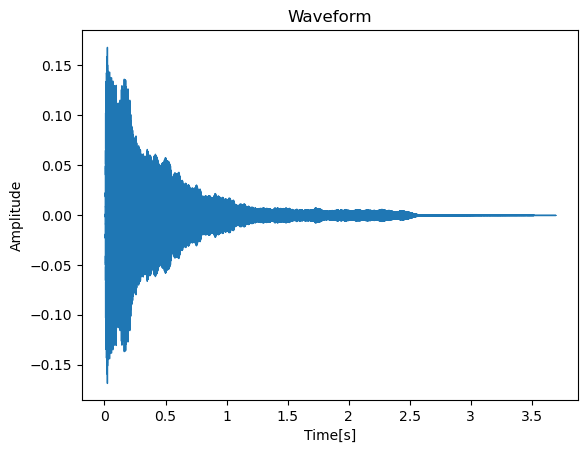

In [222]:
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.xlabel("Time[s]")
plt.ylabel("Amplitude")

In [223]:
ipd.Audio(y, rate=sr)

In [224]:
start_time = 0
end_time = 1

start_sample = int(start_time*sr)
end_sample = int(end_time*sr)

In [ ]:
a = input()

n=0

A = a[0]
B = int(a[1])

N = [16.36, 18.35, 20.6, 21.83, 24.5, 27.5, 30.87]
M = [['C', 1], ['D', 2], ['E', 3], ['F', 4], ['G', 5], ['A', 6], ['H', 7]]

for i in range(7):
    if A==M[i][0]:
        n = i


req_freq = (N[n]*(2**(B)))
req_freq

440.0

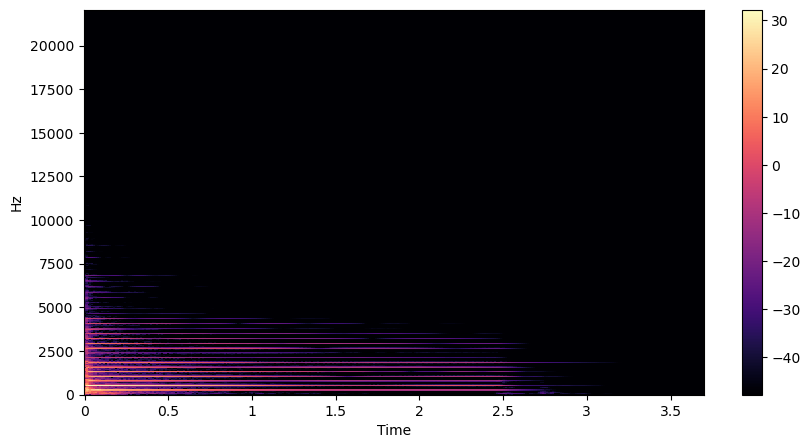

In [210]:
X = librosa.stft(y)
Xdb = librosa.amplitude_to_db(abs(X))
plt.figure(figsize = (10, 5))
librosa.display.specshow(Xdb, sr = sr, x_axis = 'time', y_axis = 'hz')
plt.colorbar()

In [275]:
a = input()

n=0

A = a[0]
B = int(a[1])

M = [['C', 1], ['C#', 2], ['D', 3], ['D#', 4], ['E', 5], ['F', 6], ['F#', 7], ['G', 8], ['G#', 9], ['A', 10], ['A#', 11], ['H', 12]]

for i in range(12):
    if A==M[i][0]:
        n = i


req_shift = (B-4)*12 + M[n][1]-1

y_shifted = librosa.effects.pitch_shift(y, sr=sr, n_steps=req_shift)
ipd.Audio(y_shifted, rate=sr)

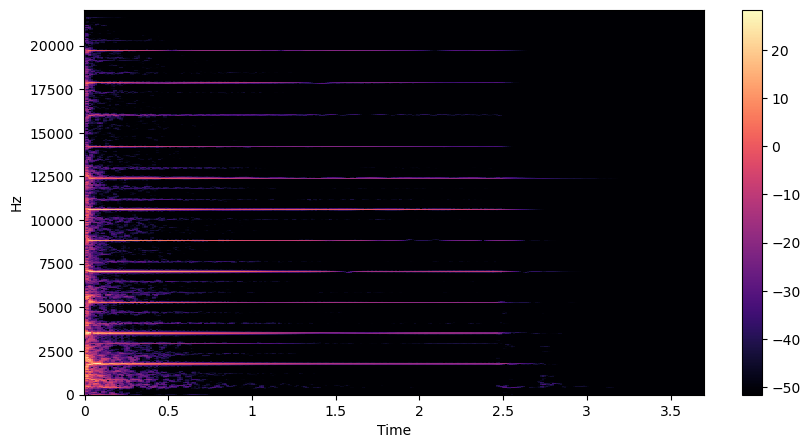

In [276]:
X = librosa.stft(y_shifted)
Xdb = librosa.amplitude_to_db(abs(X))
plt.figure(figsize = (10, 5))
librosa.display.specshow(Xdb, sr = sr, x_axis = 'time', y_axis = 'hz')
plt.colorbar()

In [ ]:
# Specifications of Filter 
  
 # sampling frequency 
f_sample = sr
  
# pass band frequency 
f_pass = 30000 
  
# stop band frequency 
f_stop = 8500
  
# pass band ripple 
fs = 0.5
  
# pass band freq in radian 
wp = f_pass/(f_sample/2)   
  
# stop band freq in radian 
ws = f_stop/(f_sample/2)  
  
# Sampling Time 
Td = 1  
  
 # pass band ripple 
g_pass = 1 
  
# stop band attenuation 
g_stop = 50

# Conversion to prewrapped analog frequency 
omega_p = (2/Td)*np.tan(wp/2) 
omega_s = (2/Td)*np.tan(ws/2) 
  
  
# Design of Filter using signal.buttord function 
N, Wn = signal.buttord(omega_p, omega_s, g_pass, g_stop, analog=True) 
  
  
# Printing the values of order & cut-off frequency! 
print("Order of the Filter=", N)  # N is the order 
# Wn is the cut-off freq of the filter 
print("Cut-off frequency= {:.3f} rad/s ".format(Wn)) 
  
  
# Conversion in Z-domain 
  
# b is the numerator of the filter & a is the denominator 
b, a = signal.butter(N, Wn, 'high', True) 
z, p = signal.bilinear(b, a, fs) 
# w is the freq in z-domain & h is the magnitude in z-domain 
w, h = signal.freqz(z, p, 512)



Order of the Filter= 5
Cut-off frequency= 1.414 rad/s 


## Sada trebam da sredim ovaj zvuk pomocu filtera